<div align='center'>

# <font color='Aqua'><b>Kakhnouski Yauheni Gr. 153503</b></font>
## <font color='Cornsilk'><b>Laboratory work №1</b></font>
## <font color='Cornsilk'><b>Getting to know Jupyter Notebook</b></font>

</div>

### <font color='Cornsilk'><b>Preparation for laboratory work</b></font> 
Import all missing libraries and read the initial data from the <b>.csv</b> files.

![Prepare](media/prepare.gif)

In [5]:
from collections import Counter
import math
import random

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme()

In [6]:
with (
    open('set_1.csv', 'r') as f1, 
    open('set_2.csv', 'r') as f2, 
    open('set_3.csv', 'r') as f3
): 
    set_1, set_2, set_3 = map(       
        lambda s: list(map(float, s.split(','))),
        [f1.read(), f2.read(), f3.read()])

<font color='Cornsilk'><b>

# Definition of Functions 
## 1. <font color='Crimson'>Expected Value</font>
The expected value of a random variable is the average value of the variable over many repetitions of the experiment. It represents what outcome can be expected on average. The expected value is denoted as E(X) or μ.
To calculate $P(x_i)$ I use Python's `collections.Counter` and divide each of its values by the total length of the data.

For a discrete random variable X, the formula for expected value is:
$$ E(X) = \sum_{i=1}^{n} x_i \cdot P(X = x_i) $$

For a continuous random variable X, the formula is:
$$ E(X) = \int_{-\infty}^{\infty} x \cdot f(x) \,dx $$

## 2. <font color='Crimson'>Variance</font>
The variance of a random variable measures the spread of values around their mean. It indicates how much the values deviate from the mean value. Variance is denoted as Var(X) or σ^2.

The formula for variance is:
$$ Var(X) = E((X - E(X))^2) $$

## 3. <font color='Crimson'>Standard Deviation</font>
The standard deviation is the square root of the variance. It is also used to measure the spread of values of a random variable around their mean. The standard deviation is denoted as SD(X) or σ.

The formula for standard deviation is:
$$\sigma(X) = \sqrt{\operatorname{Var}(X)} = \sqrt{\mathbb{E}\left[X^2\right] - \mathbb{E}\left[X\right]^2}$$

Where:
- $X$ is the random variable;
- $x_i$ are the possible values of the random variable;
- $P(X = x_i)$ is the probability of the random variable taking the value $x_i$;
- $f(x)$ is the probability density function for a continuous random variable.

</b></font>
<center>

![Math](media/calculation-math.gif)

</center>

In [7]:
def expected_value(data: list[float | int]) -> float:
    """
    Function for calculating mean value of the dataset.

    :param data: list of any numbers.
    :return: floating point number that represents mean value of the dataset.
    
    """
    counter: Counter = Counter(data)
    mean: float = sum([k * v / len(data) for k, v in counter.items()])
    
    return mean

In [8]:
def standart_deviation(data: list[float | int]) -> float:
    r"""
    Computes standard deviation of the given dataset.

    :param data: list of any numbers.
    :return: floating point number that represents standard deviation of the dataset.
    """
    std: float = math.sqrt(expected_value([s ** 2 for s in data]) - expected_value(data) ** 2)

    return std

# <font color='Cornsilk'><b>Plotting graphs on data sets from files</b></font> 

In [9]:
def remove_outliers(data: list[int | float]) -> list[int | float]:
    sigma: float = standart_deviation(data)

    return list(filter(lambda x: -3 * sigma < x and x < 3 * sigma, data))

set_1, set_2, set_3 = map(remove_outliers, [set_1, set_2, set_3])

In [10]:
set_1, set_2, set_3 = map(remove_outliers, [set_1, set_2, set_3])
set_1
set_2
set_3

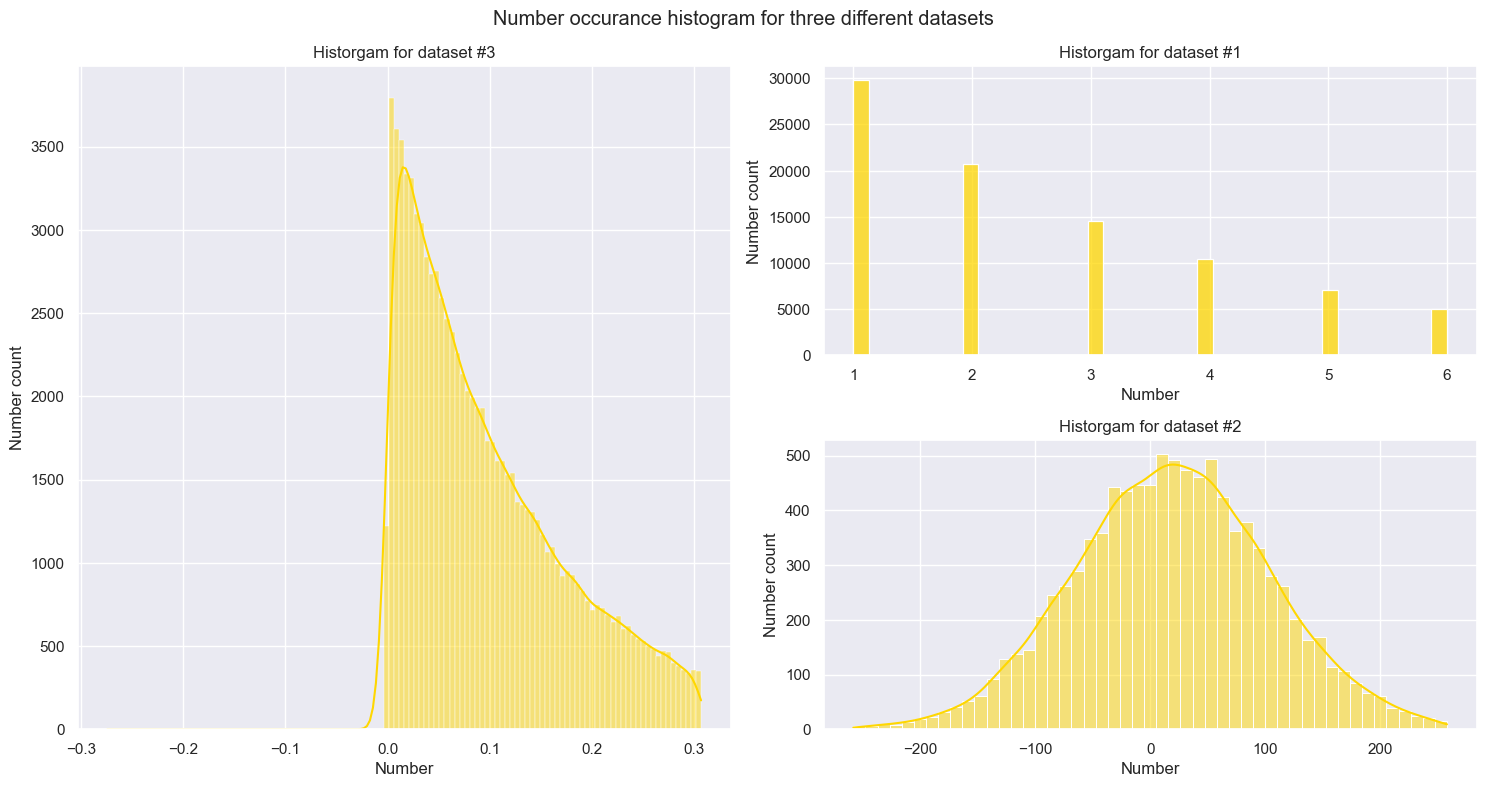

In [11]:
gold = ["#FFD700"]
sns.set_palette(gold)

fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(nrows=2, ncols=2)

ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[:, 0])

plt.suptitle('Number occurance histogram for three different datasets')

for i, (ax, set) in enumerate(zip([ax1, ax2, ax3], [set_1, set_2, set_3])):    

    sns.histplot(set, kde=(set is not set_1), ax=ax)
    ax.set_xlabel('Number')
    ax.set_ylabel('Number count')
    ax.set_title(f'Historgam for dataset #{i + 1}')

plt.tight_layout(pad=1)
plt.show()

# <font color='DeepPink'><b>Implementing theoretical data distributions in Python</b></font> 
<center>

![Sigma](media/meme-sigma.gif)

</center>

## <font color='Cornsilk'><b>Normal distribution</b></font> 

In [12]:
def normal(mean: float, std: float, n: int) -> list[float]:
    return [random.normalvariate(mean, std) for _ in range(n)]

## <font color='Cornsilk'><b>Geometric distribution</b></font> 

In [13]:
def geometric(mean: float, std: float, n: int) -> list[int]:
    while mean < 1:
        mean *= 10
        
    data: list[int] = []
    p = 1 / mean
    
    for _ in range(n):
        i = 0
        while random.choices([True, False], weights=[p, 1-p])[0]:
            i += 1
        data += [i]
    
    return data

## <font color='Cornsilk'><b>Poisson distribution</b></font> 

In [14]:
def poisson(mean: float, n: int) -> list[float]:
    data: list[float] = []
    
    for _ in range(n):
        k, p = 0, 1
        
        while True:
            if p <= math.exp(-mean):
                break
            p *= random.random()
            k += 1
            
        data += [k]
    
    return data


## <font color='Cornsilk'><b>Uniform distribution</b></font> 

In [15]:
def uniform(mean: float, std: float, n: int) -> list[float]:
    a = mean - math.sqrt(3) * std
    b = mean + math.sqrt(3) * std

    data = [random.uniform(a, b) for _ in range(n)]

    return data

## <font color='Cornsilk'><b>Binomial distribution</b></font>
<center>

![Binom](media/newton.gif)

</center>

In [16]:
def binomial(mean: float, std: float, n: int) -> list[int]:
    while std < 1:
        std *= 10
    data: list[int] = []
    #p = 1 / (std ** 2)
    p = 1 - (std ** 2) / mean
    k = int((std ** 2) / mean)

    
    data = [sum(random.choices([0, 1], weights=[p, 1-p], k=k)) for _ in range(n)]
    
    return data

## <font color='Cornsilk'><b>Exponential distribution</b></font>

In [17]:
def exponential(mean: float, n: int) -> list[float]:
    return [random.expovariate(1 / mean) for _ in range(n)]

## <font color='Cornsilk'><b> Calculating $\mu$ and $\sigma$ for each dataset and generating new distributions</b></font>

In [18]:
mu_vals = list(map(expected_value, [set_1, set_2, set_3]))
sigma_vals = list(map(standart_deviation, [set_1, set_2, set_3]))
N: int = 10000

In [19]:
distributions = [
    [
        normal(mu, sigma, N),
        uniform(mu, sigma, N), 
        poisson(mu, N), 
        geometric(mu, sigma, N), 
        exponential(mu, N), 
        binomial(mu, sigma, N)
     ]
    for i, (mu, sigma) in enumerate(zip(mu_vals, sigma_vals))
]
dist_names = ['Normal', 'Uniform', 'Poisson', 'Geometric', 'Exponential', 'Binomial']

## <font color='Cornsilk'><b> Plotting NEW distributions</b></font>
<center>

![Plotting](media/plotting-spongebob.gif)

</center>

In [20]:

spring_green = ["#00FF7F"]
sns.set_palette(spring_green)

fig = plt.figure(figsize=(18, 24))
gs = fig.add_gridspec(2 * len(distributions), 3)

for i, (dist_set, mu, sigma) in enumerate(zip(distributions, mu_vals, sigma_vals)):
    axes: list = []
    
    for j in range(2):
        for k in range(3):
            axes += [fig.add_subplot(gs[i * 2 + j, k])]

    for dist, name, ax in zip(dist_set, dist_names, axes):
        ax.set_xlabel('Number')
        ax.set_ylabel('Number count')
        ax.set_title(rf'{name} distribution with $\mu=${round(mu, 2)} and $\sigma=${round(sigma, 2)}')
        
        sns.histplot(dist, kde=(name in ['Normal', 'Exponential']), ax=ax)

plt.tight_layout()
plt.show()